### [K線捕手](https://www.facebook.com/kevinyang20180801)  

🎯今日影音已上架  
轉強還是假象？台股該進場還是觀望？  
https://smart.businessweekly.com.tw/e-subscription/article?c=GROUP00014146&p=PROD000019311&at=13&a=3144  
  
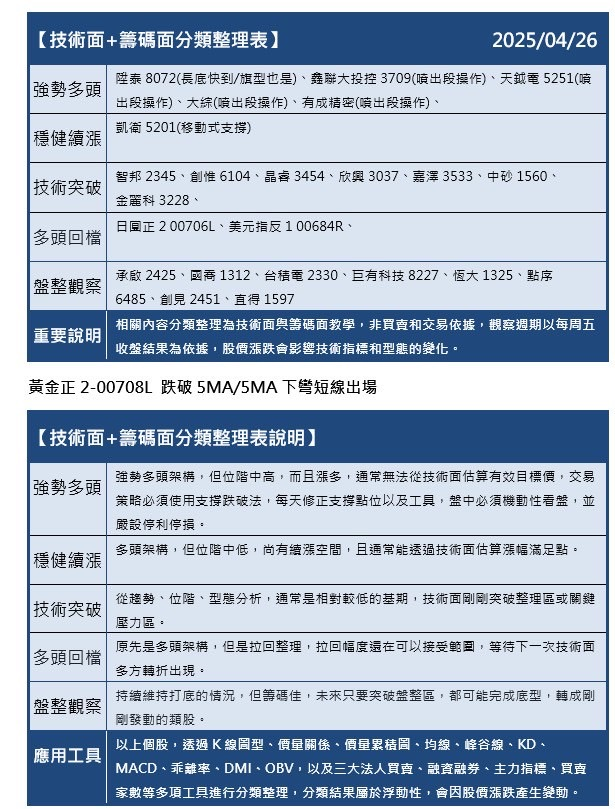  

### 本日進度  
* 量化技術分析系統：規劃與開發  
  - 型態識別機制檢討  
    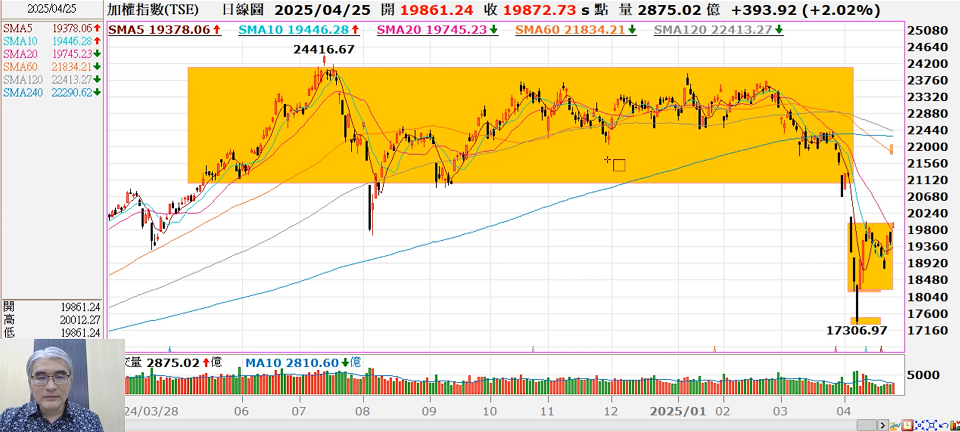  
    * 股票老師所畫的線會跳過突出部分(被視做假突破或假跌破)，但這部份難以量化。  
    * 因此還是照著**量化**規則實作型態識別機制。

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np
import myutils

In [2]:
def date_to_index(df_in,date_in) :
    number_array = df_in.index == date_in
    idx = 0
    for number_index in number_array :
        if number_index == True :
            break
        idx = idx + 1
    return idx

In [3]:
# 雛型版
def chart_pattern_recognition( prices):
    # 建立「股票技術型態識別」物件
    chart_pattern = myutils.StockChartPatterns(prices,debug=True)
    
    # 進行主要型態識別(GPT-4o版)
    patterns = chart_pattern.RecognitionUsingGPT4o()
    if patterns is None :
        return
    gpt4o_major_pattern           = patterns[0]
    gpt4o_major_pattern_type_char = '＊'
    gpt4o_major_pattern_start_idx = date_to_index(prices,gpt4o_major_pattern['start'])
    gpt4o_major_pattern_end_idx   = date_to_index(prices,gpt4o_major_pattern['end'])
    if '頂' in gpt4o_major_pattern['type'] :
        gpt4o_major_pattern_type_char = '頂'
    elif '底' in gpt4o_major_pattern['type'] :
        gpt4o_major_pattern_type_char = '底'
    print(gpt4o_major_pattern)
    
    # 進行型態識別
    turning_point_args = []
    turning_point_args.append({'mode':'close', 'order':10, 'smoothing':3})
    turning_point_args.append({'mode':'open_close', 'order':5})
    turning_point_args.append({'mode':'open_close', 'order':10})
    turning_point_args.append({'mode':'open_close', 'order':15})
    turning_point_args.append({'mode':'open_close', 'order':20})
    turning_point_args.append({'mode':'open_close', 'order':25})
    turning_point_args.append({'mode':'open_close', 'order':30})
    patterns = chart_pattern.Recognition(max_bars=360, turning_point_args=turning_point_args)
    
    # 頭部或底部
    pattern_suitable_distance = sys.maxsize
    candidate_pattern         = None
    for pattern_name in patterns:
        if gpt4o_major_pattern_type_char in pattern_name :
            for pattern in patterns[pattern_name] :
                window            = pattern['window']
                pattern_start_idx = window.iloc[1].name
                pattern_end_idx   = window.iloc[-1].name
                pattern_distance  = abs(gpt4o_major_pattern_start_idx - pattern_start_idx) + abs(gpt4o_major_pattern_end_idx - pattern_end_idx)
                if pattern_distance < pattern_suitable_distance :
                    print('pattern_name = {} , gpt4o_major_pattern_start_idx = {} , gpt4o_major_pattern_end_idx = {} , pattern_start_idx = {} , pattern_end_idx = {} '.format(pattern_name,gpt4o_major_pattern_start_idx,gpt4o_major_pattern_end_idx,pattern_start_idx,pattern_end_idx))
                    pattern_suitable_distance = pattern_distance
                    candidate_pattern         = [pattern_name,pattern['argument'],pattern['window']]
    if candidate_pattern is not None :
        pattern_name   = candidate_pattern[0]
        pattern_window = candidate_pattern[2]
        seq_of_seq_of_points = []
        if pattern_name == '雙重頂' or pattern_name == '雙重底':
            pattern_first_date_idx  = pattern_window.iloc[0].name
            pattern_start_date_idx  = pattern_window.iloc[1].name
            neckline_start_date_idx = gpt4o_major_pattern_start_idx
            neckline_end_date_idx   = gpt4o_major_pattern_end_idx
            neckline_start_date     = prices.iloc[neckline_start_date_idx].name.strftime("%Y-%m-%d")
            neckline_end_date       = prices.iloc[neckline_end_date_idx].name.strftime("%Y-%m-%d")
            neckline_start_price    = pattern_window.iloc[2]['Price']
            neckline_end_price      = pattern_window.iloc[2]['Price']
            # 設定頸線
            seq_of_seq_of_points=[[(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)]]
        elif pattern_name == '三重頂' or pattern_name == '三重底' or pattern_name == '頭肩頂' or pattern_name == '頭肩底' :
            pattern_first_date_idx  = pattern_window.iloc[0].name
            pattern_start_date_idx  = pattern_window.iloc[1].name
            neckline_start_date_idx = gpt4o_major_pattern_start_idx
            neckline_end_date_idx   = gpt4o_major_pattern_end_idx
            neckline_start_date     = prices.iloc[neckline_start_date_idx].name.strftime("%Y-%m-%d")
            neckline_end_date       = prices.iloc[neckline_end_date_idx].name.strftime("%Y-%m-%d")
            neckline_x              = [date_to_index(prices,pattern_window.iloc[2]['Date']),date_to_index(prices,pattern_window.iloc[4]['Date'])]
            neckline_y              = [pattern_window.iloc[2]['Price'],pattern_window.iloc[4]['Price']]
            neckline_slope,neckline_intercept = np.polyfit(neckline_x,neckline_y,1)
            neckline_start_price    = neckline_slope * date_to_index(prices,neckline_start_date) + neckline_intercept
            neckline_end_price     = neckline_slope * date_to_index(prices,neckline_end_date) + neckline_intercept
            # 設定頸線
            seq_of_seq_of_points=[[(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)]]
        # 設定K線格式
        mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
        s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)        
        # 設定轉折點
        turning_points_len = len(np.array(prices['Close']))
        turning_points = np.array([np.nan]*turning_points_len)
        for point in pattern_window.iterrows() :
            turning_points[point[0]] = point[1]['Price']
        apds = [mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=25,color='xkcd:sky blue')]
        # 繪製K線圖
        kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True, addplot=apds, alines=dict(alines=seq_of_seq_of_points, linewidths=2, colors='xkcd:orange yellow', alpha=0.6), datetime_format='%Y-%m-%d', warn_too_much_data=2000)
        mpf.plot(prices,**kwargs)
    else :
        # 設定區間價格
        range_price = prices[gpt4o_major_pattern['start']:gpt4o_major_pattern['end']]
        # 設定趨勢線
        range_chart_pattern  = myutils.StockChartPatterns(range_price,debug=True)
        _,lines              = chart_pattern.TrendlineAutomation(mode='open_close')
        seq_of_seq_of_points = lines
        # 設定K線格式
        mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
        s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
        # 繪製K線圖
        kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True, alines=dict(alines=seq_of_seq_of_points, linewidths=1.5, colors=('xkcd:cherry red','xkcd:electric blue'), alpha=0.6), datetime_format='%Y-%m-%d', warn_too_much_data=2000)
        mpf.plot(prices,**kwargs)
    
    # 底型反轉操作法之底部型態
    if gpt4o_major_pattern_type_char == '底' :
        patterns = chart_pattern.RecognitionBottom()
        if patterns is None or len(patterns) == 0 :
            return
        # 只畫出最後一個底部型態
        bottom_pattern = patterns[-1]['bottom_pattern']
        bottom_pattern_breakout = False
        if 'bottom_pattern_breakout_date' in bottom_pattern :
            bottom_pattern_breakout_date  = bottom_pattern['bottom_pattern_breakout_date']
            bottom_pattern_breakout_price = bottom_pattern['bottom_pattern_breakout_price']
            bottom_pattern_breakout = True
        neckline_start_date  = bottom_pattern['neckline_start_date']
        neckline_start_price = bottom_pattern['neckline_start_price']
        neckline_end_date    = bottom_pattern['neckline_end_date']
        neckline_end_price   = bottom_pattern['neckline_end_price']
        bottom_price_date    = bottom_pattern['bottom_price_date']
        bottom_price         = bottom_pattern['bottom_price']
        on_neckline_price    = bottom_pattern['on_neckline_price']
        target_price         = bottom_pattern['target_price']
    
        # 設定K線格式
        mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
        s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

        # 設定頸線
        if bottom_pattern_breakout is True :
            seq_of_seq_of_points=[
                [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)],
                [(bottom_price_date,bottom_price),(bottom_price_date,on_neckline_price)],
                [(bottom_pattern_breakout_date,bottom_pattern_breakout_price),(bottom_pattern_breakout_date,target_price)]
            ]
        else :
            seq_of_seq_of_points=[
                [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)],
                [(bottom_price_date,bottom_price),(bottom_price_date,on_neckline_price)],
                [(neckline_end_date,neckline_end_price),(neckline_end_date,target_price)]
            ]
    
        # 繪製K線圖
        kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True, alines=dict(alines=seq_of_seq_of_points, linewidths=(1.2,10,10), colors='xkcd:orange yellow', alpha=0.6), datetime_format='%Y-%m-%d', warn_too_much_data=2000)
        mpf.plot(prices,**kwargs)

In [4]:
##### 使用2023年8月21日到2025年4月25日收盤之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_TSE_250425.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

{'type': '頭肩頂', 'start': '2024-04-01', 'end': '2025-03-17'}
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}, {'mode': 'open_close', 'order': 10}, {'mode': 'open_close', 'order': 15}, {'mode': 'open_close', 'order': 20}, {'mode': 'open_close', 'order': 25}, {'mode': 'open_close', 'order': 30}]
pattern_name = 雙重頂 , gpt4o_major_pattern_start_idx = 148 , gpt4o_major_pattern_end_idx = 378 , pattern_start_idx = 296 , pattern_end_idx = 316 
pattern_name = 雙重頂 , gpt4o_major_pattern_start_idx = 148 , gpt4o_major_pattern_end_idx = 378 , pattern_start_idx = 152 , pattern_end_idx = 186 
pattern_name = 雙重頂 , gpt4o_major_pattern_start_idx = 148 , gpt4o_major_pattern_end_idx = 378 , pattern_start_idx = 217 , pattern_end_idx = 282 
pattern_name = 三重頂 , gpt4o_major_pattern_start_idx = 148 , gpt4o_major_pattern_end_idx = 378 , pattern_start_idx = 217 , pattern_end_idx = 296 
pattern_name = 三重頂 , gpt4o_major_pattern_start_idx = 148 , gpt4o_major_patte

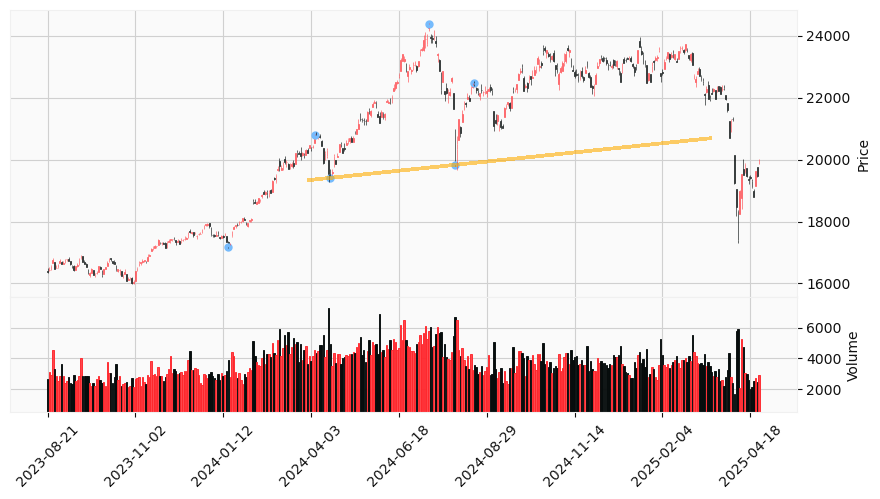

In [5]:
chart_pattern_recognition(df_k_line)

In [6]:
##### 使用2022年2月25日到2023年3月9日之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_6274_230309.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

{'type': '頭肩底', 'start': '2022-06-09', 'end': '2023-03-09'}
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}, {'mode': 'open_close', 'order': 10}, {'mode': 'open_close', 'order': 15}, {'mode': 'open_close', 'order': 20}, {'mode': 'open_close', 'order': 25}, {'mode': 'open_close', 'order': 30}]
pattern_name = 頭肩底 , gpt4o_major_pattern_start_idx = 63 , gpt4o_major_pattern_end_idx = 245 , pattern_start_idx = 104 , pattern_end_idx = 204 


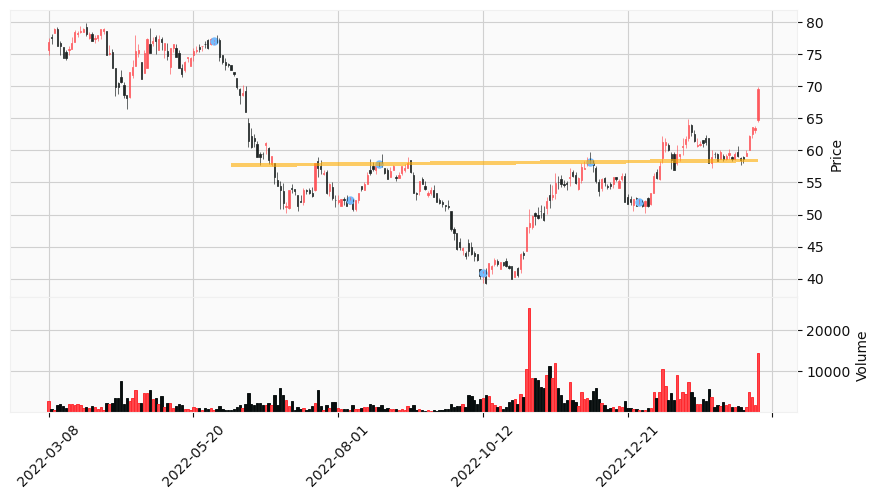

ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'open_close', 'order': 5}]
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 9） 
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 83 （日期 ＝ 2022-07-07 ） ， 底部型態結束索引 ＝ 211 （日期 ＝ 2023-01-06 ）
ＤＥＢＵＧ ： 頸線角度（絕對值） ＝ 0.46°
ＤＥＢＵＧ ： 底部型態突破確認範圍 ： 211 ～ 231
ＤＥＢＵＧ ： 確認底部型態突破，收盤價超過頸線３％。價格索引 ＝ 212 ， 日期 ＝ 2023-01-09 ， 突破時頸線價格 ＝ 58.36元 
ＤＥＢＵＧ ： 底部最低價格 ＝ 39.40元 ； 估算目標價 ＝ 77.42元


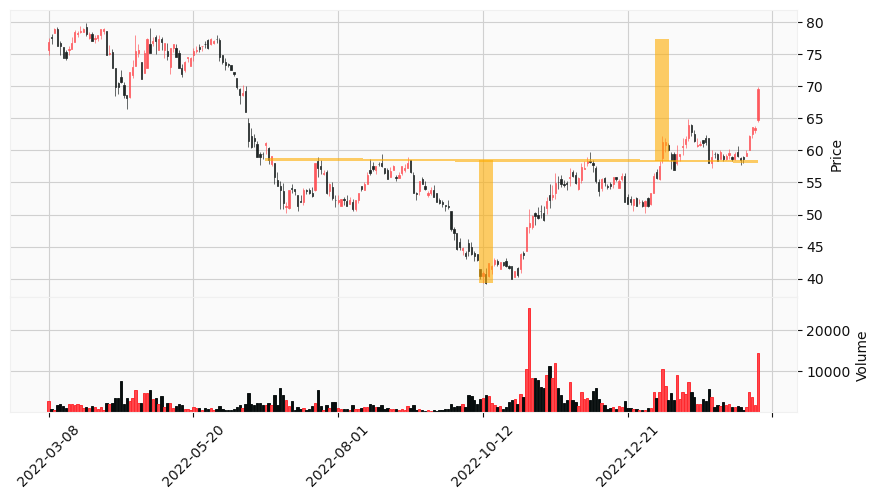

In [7]:
chart_pattern_recognition(df_k_line)